# Projection and Cosine Similarity

**This notebook is self-contained; it recaps the dot product before using it.**

Recall the **dot product** $\mathbf{v}\cdot\mathbf{w} = \sum_i v_i w_i$, equivalently a row times a column, $\mathbf{v}^{\top}\mathbf{w}$, and the length $\|\mathbf{v}\| = \sqrt{\mathbf{v}\cdot\mathbf{v}}$. (Vectors are written as **columns** throughout; the transposed row form shows up only inside a dot product.) Two powerful ideas build directly on them: **projection** (how much of one vector points along another, the shadow it casts) and **cosine similarity** (a number from −1 to 1 saying how alike two vectors' *directions* are). Cosine similarity is how search engines and recommender systems decide that two patients, documents, or products are "similar."

## Learning objectives

- Compute the **projection** of one vector onto another.
- Compute **cosine similarity** and interpret its value.
- Use cosine similarity to compare several data points at once.

## Background

The **projection** of $\mathbf{v}$ onto $\mathbf{w}$ is the part of $\mathbf{v}$ that lies along $\mathbf{w}$:

$$\text{proj}_{\mathbf{w}}(\mathbf{v}) = \frac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{w}\|^2}\,\mathbf{w}.$$

**Cosine similarity** is just $\cos\theta$, the angle formula from the previous notebook, reused as a similarity score:

$$\text{cossim}(\mathbf{v}, \mathbf{w}) = \frac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{v}\|\,\|\mathbf{w}\|}.$$

It is $1$ when the vectors point the same way, $0$ when they are orthogonal, and $-1$ when they point opposite ways, and it ignores length, comparing only **direction**.

## This notebook covers

1. Projecting one vector onto another.
2. Cosine similarity of two vectors.
3. Comparing several data points (a similarity table).

**Prerequisites:** `U2-2_Vectors-2_DotProductAndAngle`

**Dataset:** none, small feature vectors entered inline (think patients or documents).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.patches import Arc

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

# --- plotting helper: draw x-y graphs like the usual coordinate plane ---
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- plotting helper: draw one vector as an arrow starting at `tail` ---
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles="xy", scale_units="xy",
              scale=1, color=color, label=label, alpha=alpha, width=0.008)

# --- plotting helper: mark the angle between two vectors with an arc at the origin ---
def draw_angle(ax, v, w, radius=1.0, color="white", label=None):
    a1 = math.degrees(math.atan2(v[1], v[0])) % 360
    a2 = math.degrees(math.atan2(w[1], w[0])) % 360
    start, end = sorted([a1, a2])
    if end - start > 180:                 # always sweep the smaller of the two angles
        start, end = end, start + 360
    ax.add_patch(Arc((0, 0), 2*radius, 2*radius, theta1=start, theta2=end,
                     color=color, lw=1.5))
    if label:
        mid = math.radians((start + end) / 2)
        ax.text(1.35*radius*math.cos(mid), 1.35*radius*math.sin(mid), label,
                color=color, ha="center", va="center", fontsize=9)

## 1. Projecting one vector onto another

The projection of $\mathbf{v}$ onto $\mathbf{w}$ is the shadow $\mathbf{v}$ casts along the line of $\mathbf{w}$, imagine light shining straight down onto $\mathbf{w}$. The formula scales $\mathbf{w}$ by how much of $\mathbf{v}$ aligns with it.

The angle is doing the work here too. The shadow's length is $\|\mathbf{v}\|\cos\theta$: at $\theta = 0^\circ$ the shadow is all of $\mathbf{v}$, and as $\theta$ opens toward $90^\circ$ it shrinks to nothing. Note the dashed line dropping from $\mathbf{v}$ to the shadow meets $\mathbf{w}$ at a **right angle**, that perpendicular drop is what makes it a projection.

*(The plotting code is just graphics, the projection and the dashed perpendicular are the point.)*

<IPython.core.display.Math object>

angle between v and w = 45.0 degrees


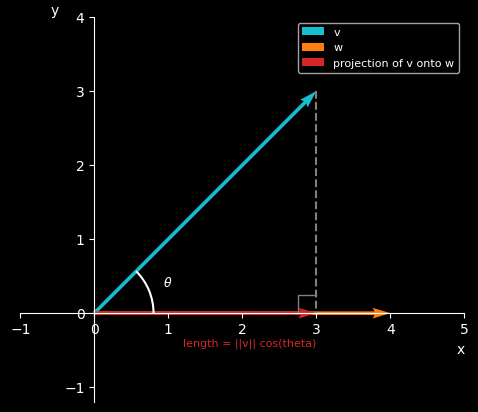

In [2]:
v = np.array([3.0, 3.0])
w = np.array([4.0, 0.0])

# projection formula: (v . w / w . w) * w
scale = np.dot(v, w) / np.dot(w, w)
projection = scale * w
helpers.show(projection, name=r"\text{proj}_w(v)")

theta = math.degrees(math.acos(np.dot(v, w) / (np.linalg.norm(v) * np.linalg.norm(w))))
print("angle between v and w =", round(theta, 1), "degrees")

# --- graphics ---
fig, ax = plt.subplots(figsize=(7, 5))
arrow(ax, (0, 0), v, "tab:cyan", "v")
arrow(ax, (0, 0), w, "tab:orange", "w")
arrow(ax, (0, 0), projection, "tab:red", "projection of v onto w")

ax.plot([v[0], projection[0]], [v[1], projection[1]], "--", color="gray")   # perpendicular drop
ax.plot([projection[0] - 0.25, projection[0] - 0.25, projection[0]],
        [0, 0.25, 0.25], color="gray", lw=1)                               # right-angle marker
draw_angle(ax, v, w, radius=0.8, label=r"$\theta$")
ax.text(1.2, -0.45, "length = ||v|| cos(theta)", color="tab:red", fontsize=8)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1, 5); ax.set_ylim(-1.2, 4); ax.set_aspect("equal"); ax.legend(fontsize=8)
plt.show()

## 2. Cosine similarity of two vectors

Cosine similarity is the cosine of the **angle** between two vectors. Because it divides out both lengths, it measures only **direction**, two patients with the same *pattern* of features score near 1 even if one has larger numbers overall.

The left plot below makes the angles visible. $\mathbf{w}$ is just a longer copy of $\mathbf{v}$, so the angle between them is $0^\circ$ and the score is $1$, the extra length is invisible to the measure. $\mathbf{u}$ sits at $90^\circ$ from $\mathbf{v}$, so it scores $0$.

The right plot is the whole scale at once: as the angle opens from $0^\circ$ to $180^\circ$, the score slides smoothly from $1$ (same direction) through $0$ (perpendicular, nothing in common) down to $-1$ (opposite directions).

cossim(v, w) = 1.0 (same direction -> ~1)
cossim(v, u) = 0.0 (perpendicular -> ~0)


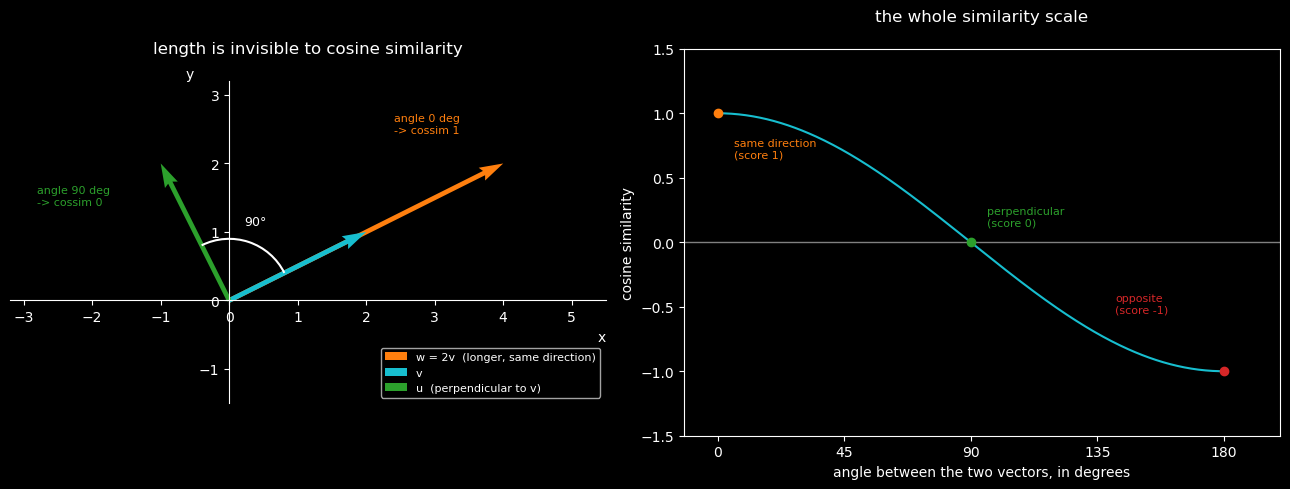

In [3]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

v = np.array([2, 1])
w = np.array([4, 2])     # same direction as v, just longer
u = np.array([-1, 2])    # perpendicular to v

print("cossim(v, w) =", round(cosine_similarity(v, w), 3), "(same direction -> ~1)")
print("cossim(v, u) =", round(cosine_similarity(v, u), 3), "(perpendicular -> ~0)")

# --- graphics: the angles behind those two scores, and the full -1..1 scale ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: the three vectors, with the angle from v marked
ax = axes[0]
arrow(ax, (0, 0), w, "tab:orange", "w = 2v  (longer, same direction)")
arrow(ax, (0, 0), v, "tab:cyan", "v")
arrow(ax, (0, 0), u, "tab:green", "u  (perpendicular to v)")
draw_angle(ax, v, u, radius=0.9, label=r"$90\degree$")
ax.text(2.4, 2.45, "angle 0 deg\n-> cossim 1", color="tab:orange", fontsize=8)
ax.text(-2.8, 1.4, "angle 90 deg\n-> cossim 0", color="tab:green", fontsize=8)
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-3.2, 5.5); ax.set_ylim(-1.5, 3.2); ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("length is invisible to cosine similarity", pad=20)

# right: the score as the angle between two vectors opens up
ax = axes[1]
theta = np.linspace(0, 180, 361)
ax.plot(theta, np.cos(np.radians(theta)), color="tab:cyan")
ax.axhline(0, color="gray", lw=1)
for deg, txt, color, off in [(0, "same direction\n(score 1)", "tab:orange", (12, -32)),
                             (90, "perpendicular\n(score 0)", "tab:green", (12, 12)),
                             (180, "opposite\n(score -1)", "tab:red", (-78, 42))]:
    ax.plot(deg, math.cos(math.radians(deg)), "o", color=color)
    ax.annotate(txt, (deg, math.cos(math.radians(deg))), textcoords="offset points",
                xytext=off, color=color, fontsize=8)
ax.set_xlabel("angle between the two vectors, in degrees")
ax.set_ylabel("cosine similarity")
ax.set_xticks([0, 45, 90, 135, 180])
ax.set_xlim(-12, 200); ax.set_ylim(-1.5, 1.5)
ax.set_title("the whole similarity scale", pad=20)

plt.tight_layout()
plt.show()

## 3. Comparing several data points

With more than two vectors we can build a **similarity table**: the cosine similarity of every pair. Here four "patients" each have two lab values, stored as a **column** of the DataFrame, so every column is one feature vector, the same column convention we write on paper. Two features (rather than more) is what lets us *draw* the patients, so the picture and the table say the same thing.

The two panels below are the same information twice:

- **Left: the vectors themselves.** Each patient is an arrow. P1 and P2 point along nearly the same direction (P2 is just a longer version of P1: a patient with the same *pattern* of results, at higher values); P3 and P4 form a second direction. Only the *angles* matter, so the four arrows fall into two obvious groups.
- **Right: the similarity table.** Every pair scored and shaded. The bright cells are the pairs whose arrows are nearly parallel; the dark cells are the pairs separated by a wide angle (marked on the left plot for P1 vs P3).

Reading a heatmap is how you would do this with 50 features, where drawing arrows is no longer possible, but the geometry on the left is what the numbers on the right always mean.

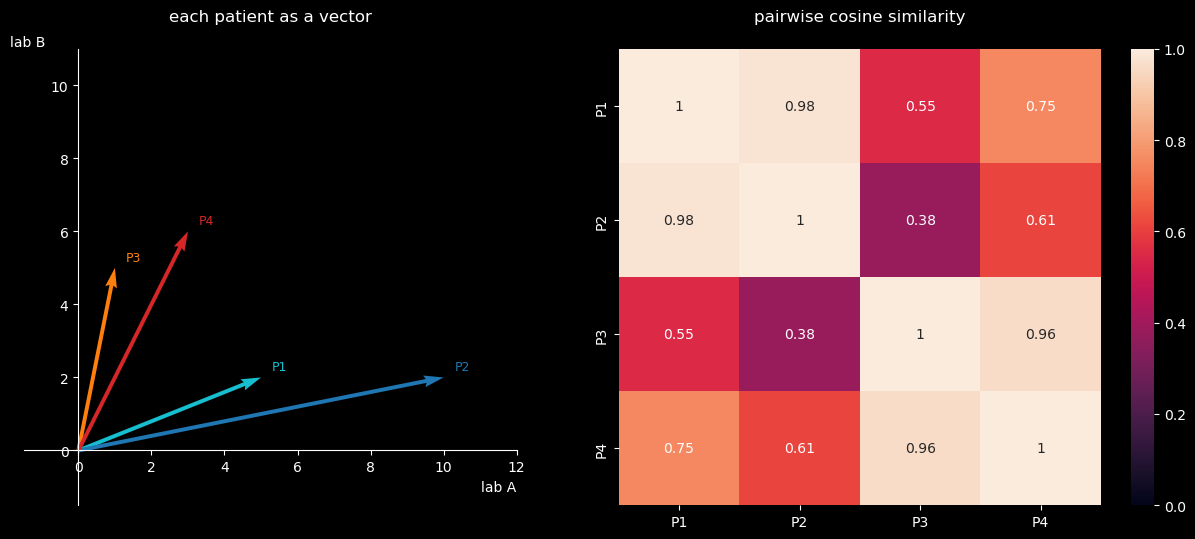

In [4]:
# each column is one patient: two lab values, so each patient is a vector we can draw
patients = pd.DataFrame({
    "P1": [5, 2],
    "P2": [10, 2],   # exactly 2 x P1: same pattern, larger values
    "P3": [1, 5],    # a different pattern
    "P4": [3, 6],    # close to P3's pattern, but not identical
}, index=["lab A", "lab B"])

names = list(patients.columns)
n = len(names)

# fill an n x n table of pairwise cosine similarities with plain loops
similarity = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        a = patients[names[i]].values
        b = patients[names[j]].values
        similarity[i, j] = cosine_similarity(a, b)

similarity_table = pd.DataFrame(similarity, index=names, columns=names).round(2)

# --- graphics: the same four patients as arrows (left) and as a table (right) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
colors = {"P1": "tab:cyan", "P2": "tab:blue", "P3": "tab:orange", "P4": "tab:red"}
for name in names:
    p = patients[name].values
    arrow(ax, (0, 0), p, colors[name])
    ax.text(p[0] + 0.3, p[1] + 0.2, name, color=colors[name], fontsize=9)

center_axes(ax)
ax.set_xlabel("lab A", loc="right")
ax.set_ylabel("lab B", loc="top", rotation=0)
ax.set_xlim(-1.5, 12); ax.set_ylim(-1.5, 11); ax.set_aspect("equal")
ax.set_title("each patient as a vector", pad=20)

sns.heatmap(similarity_table, annot=True, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("pairwise cosine similarity", pad=20)

plt.tight_layout()
plt.show()

The two panels agree, cell for cell. Read the table against the arrows:

- **P1 to P2 sits at the ceiling.** P2 is precisely twice P1, so the two arrows lie on the same line: zero angle between them: and the doubled lab values are completely invisible to the measure.
- **P3 to P4 scores just below it.** Nearly the same direction, but not quite, so a *very* similar patient still falls short of the ceiling.
- **The dark cells are the cross-group pairs**, separated by a wide angle: the pairing marked on the left plot.

That two-bright-blocks pattern is exactly how a recommender reads the table: the bright blocks are the groups.

## 4. Summary

- **Projection** $\text{proj}_{\mathbf{w}}(\mathbf{v}) = \dfrac{\mathbf{v}\cdot\mathbf{w}}{\|\mathbf{w}\|^2}\mathbf{w}$ is the part of $\mathbf{v}$ along $\mathbf{w}$; its length is $\|\mathbf{v}\|\cos\theta$.
- **Cosine similarity** $= \cos\theta$ scores direction alignment from $-1$ to $1$, ignoring length.
- A table of pairwise cosine similarities reveals which data points group together, the basis of recommenders. With two features you can check it against the picture; with fifty you have only the table, but it means the same thing.

Next: which points you can **reach** by scaling and adding vectors, linear combinations and
**span** (`U2-2_Vectors-4_LinearCombinationsAndSpan`).